# Thread 2: Gender Injustice

### This thread looks at the crimes against women in the past decade and concludes important pointers from it. For ex- how the rate of crime against women is affected each year, whether criminals are convicted, etc.

## Analysis

# Importing Libraries

In [54]:
import sys
sys.path.append("..")
import utility as u
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib
importlib.reload(u)

<module 'utility' from '/Users/bhavya/Documents/DS/The Committee Will Look Into It/02_Gender_Injustice/../utility.py'>

## Loading Data files

In [55]:
csv1= u.load_data("data/cleaned/file1.csv")
csv2= u.load_data("data/cleaned/file2.csv")
csv3= u.load_data("data/cleaned/file3.csv")
csv4= u.load_data("data/cleaned/file4.csv")
csv5= u.load_data("data/cleaned/file5.csv")
csv6= u.load_data("data/cleaned/file6.csv")
csv7= u.load_data("data/cleaned/file7.csv")

## a. csv1 Analysis

In [56]:
csv1.columns

Index(['CRIME HEAD', 'year', 'cases'], dtype='object')

Chart saved- charts/csv1_01_multiline_crime_heads.png


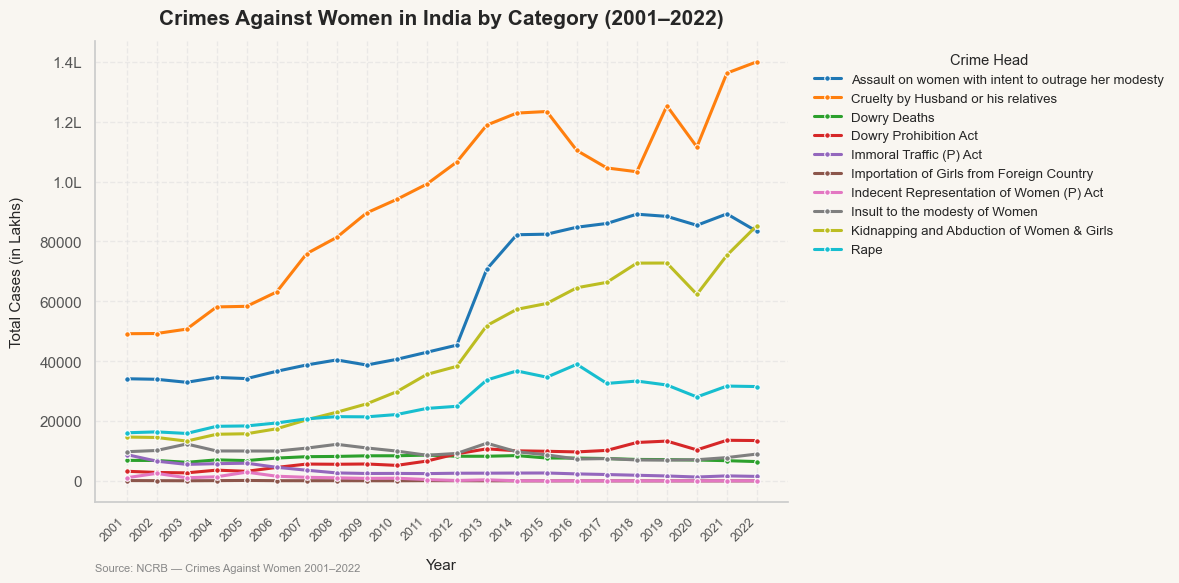

In [57]:
crime_by_year = csv1.groupby(["year", "CRIME HEAD"])["cases"].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

sns.lineplot(
    data=crime_by_year,
    x="year",
    y="cases",
    hue="CRIME HEAD",
    palette="tab10",
    linewidth=2.2,
    marker="o",
    markersize=4,
    ax=ax,
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))

ax.set_xticks(crime_by_year["year"].unique())
ax.set_xticklabels(
    crime_by_year["year"].unique(), rotation=45, ha="right", fontsize=9
)

ax.legend(
    title="Crime Head",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9.5,
    title_fontsize=10.5,
)

ax.set_title(
    "Crimes Against Women in India by Category (2001–2022)",
    fontsize=15,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Total Cases (in Lakhs)", fontsize=11)

u.add_source(ax, "NCRB — Crimes Against Women 2001–2022")

plt.tight_layout()
u.save_fig(fig, "charts", "csv1_01_multiline_crime_heads.png")
plt.show()

Chart saved- charts/csv1_02_stacked_area_composition.png


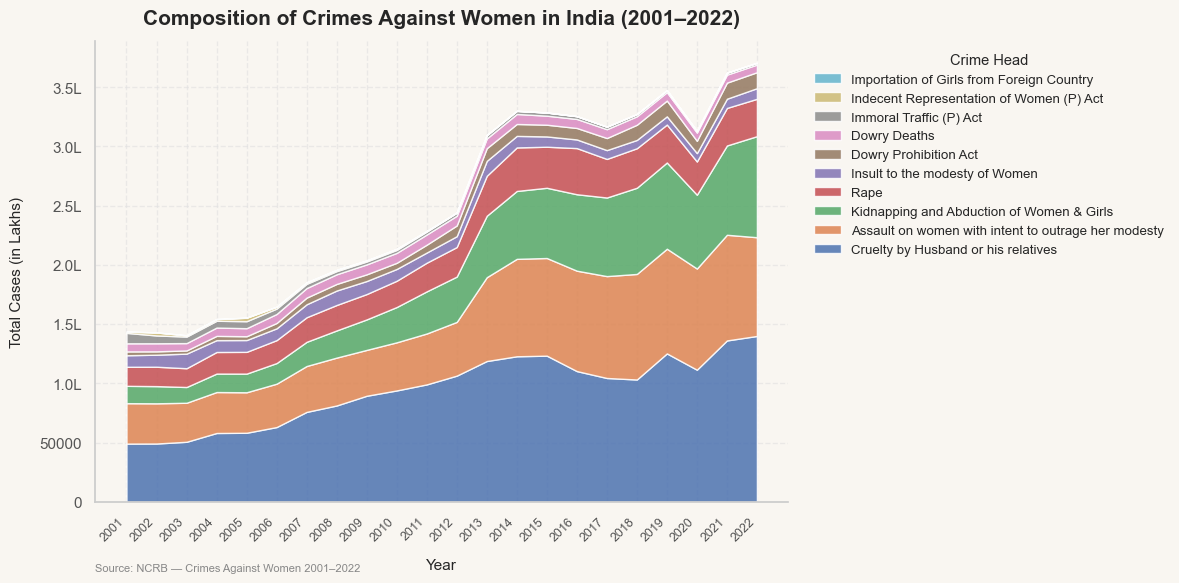

In [58]:
pivot_df = csv1.pivot_table(
    index="year", columns='CRIME HEAD', values="cases", aggfunc="sum"
).fillna(0)

column_order = pivot_df.sum().sort_values(ascending=False).index
pivot_df = pivot_df[column_order]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

ax.stackplot(
    pivot_df.index,
    pivot_df.T,
    labels=pivot_df.columns,
    alpha=0.85,
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))

ax.set_xticks(pivot_df.index)
ax.set_xticklabels(pivot_df.index, rotation=45, ha="right", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Crime Head",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9.5,
    title_fontsize=10.5,
)

ax.set_title(
    "Composition of Crimes Against Women in India (2001–2022)",
    fontsize=15,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Total Cases (in Lakhs)", fontsize=11)

u.add_source(ax, "NCRB — Crimes Against Women 2001–2022")

plt.tight_layout()
u.save_fig(fig, "charts", "csv1_02_stacked_area_composition.png")
plt.show()

Chart saved- charts/csv1_03_total_crimes_annotated.png


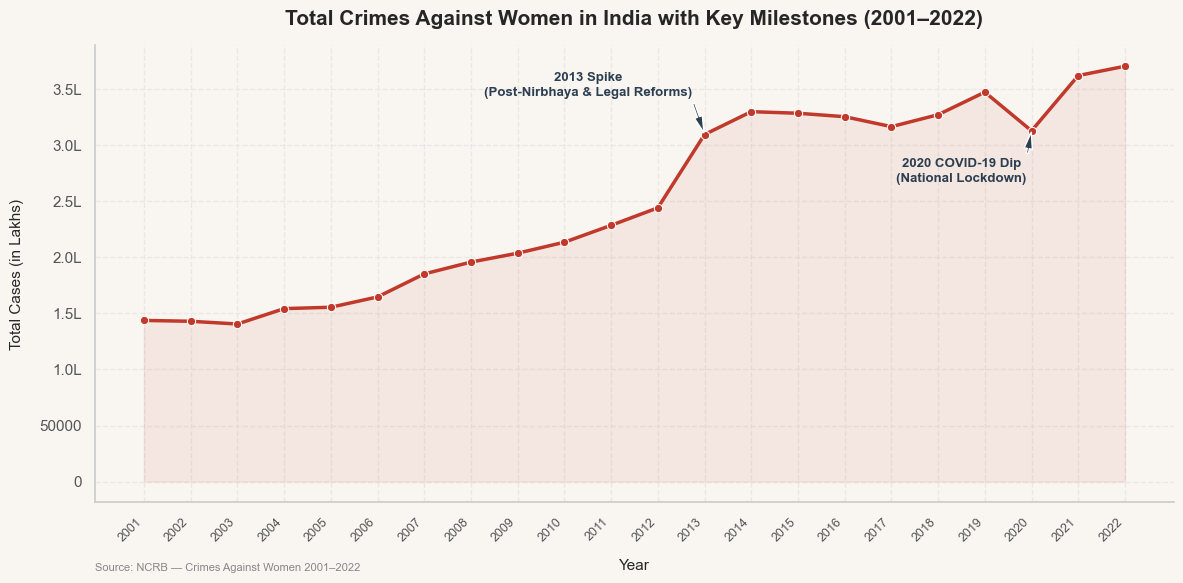

In [59]:
total_per_year = csv1.groupby("year")["cases"].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

sns.lineplot(
    data=total_per_year,
    x="year",
    y="cases",
    color="#c0392b",
    linewidth=2.5,
    marker="o",
    markersize=6,
    ax=ax,
)

ax.fill_between(
    total_per_year["year"],
    total_per_year["cases"],
    alpha=0.08,
    color="#c0392b",
)

# 2013 Spike (Post-Nirbhaya & Criminal Law Amendment Act)
val_2013 = total_per_year.loc[total_per_year["year"] == 2013, "cases"].values[0]
ax.annotate(
    "2013 Spike\n(Post-Nirbhaya & Legal Reforms)",
    xy=(2013, val_2013),
    xytext=(2010.5, val_2013 + 35000),
    arrowprops=dict(facecolor="#2c3e50", shrink=0.05, width=1.5, headwidth=6),
    fontsize=9.5,
    fontweight="bold",
    color="#2c3e50",
    ha="center",
)

# 2020 Dip (COVID-19 Lockdowns)
val_2020 = total_per_year.loc[total_per_year["year"] == 2020, "cases"].values[0]
ax.annotate(
    "2020 COVID-19 Dip\n(National Lockdown)",
    xy=(2020, val_2020),
    xytext=(2018.5, val_2020 - 45000),
    arrowprops=dict(facecolor="#2c3e50", shrink=0.05, width=1.5, headwidth=6),
    fontsize=9.5,
    fontweight="bold",
    color="#2c3e50",
    ha="center",
)

# 6. Y-Axis Formatting & X-Axis Ticks
ax.yaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))
ax.set_xticks(total_per_year["year"])
ax.set_xticklabels(total_per_year["year"], rotation=45, ha="right", fontsize=9)

# 7. Labels, Titles & Utility Source Watermark
ax.set_title(
    "Total Crimes Against Women in India with Key Milestones (2001–2022)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Total Cases (in Lakhs)", fontsize=11)

u.add_source(ax, "NCRB — Crimes Against Women 2001–2022")

# 8. Layout & Export using utility.save_fig
plt.tight_layout()
u.save_fig(fig, "charts", "csv1_03_total_crimes_annotated.png")
plt.show()

Chart saved- charts/csv1_05_pct_change_bar_chart.png


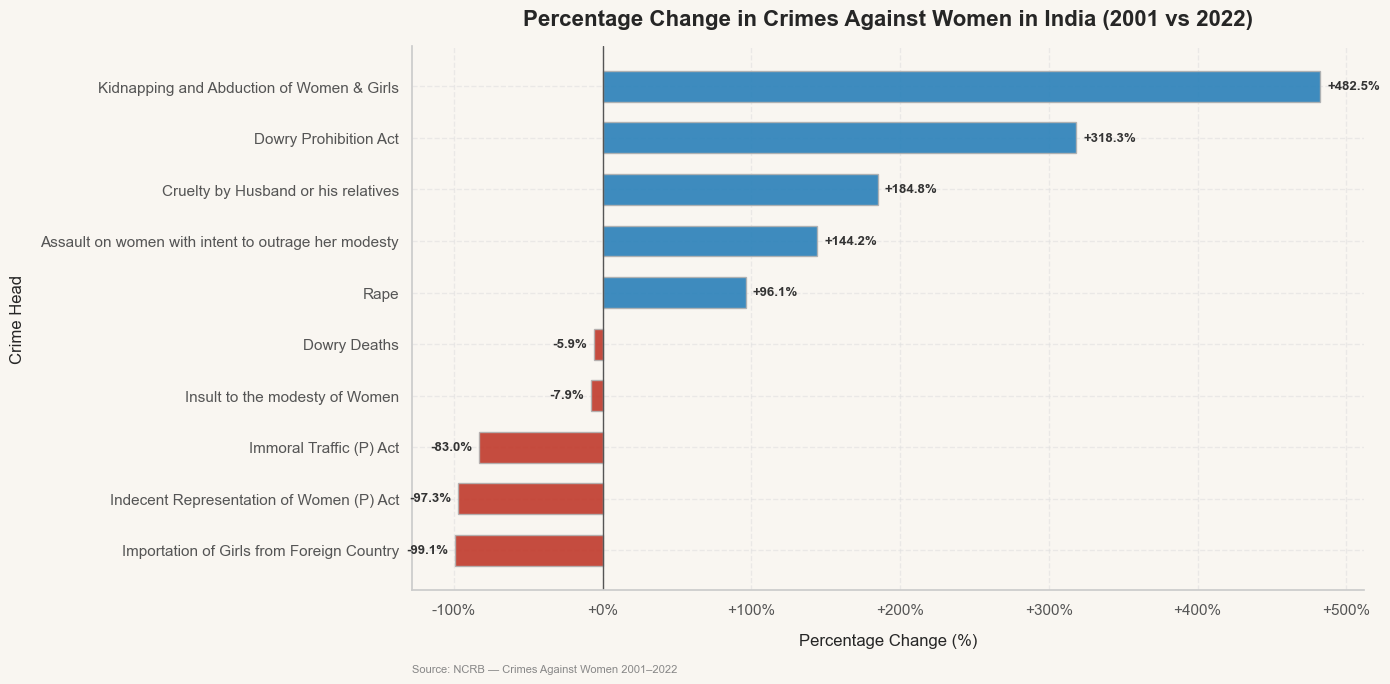

In [60]:
u.set_style()


# 3. Calculate percentage change from 2001 to 2022 per crime head
csv1_2001 = csv1[csv1["year"] == 2001].set_index("CRIME HEAD")["cases"]
csv1_2022 = csv1[csv1["year"] == 2022].set_index("CRIME HEAD")["cases"]

pct_change = ((csv1_2022 - csv1_2001) / csv1_2001 * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#c0392b" if x < 0 else "#2980b9" for x in pct_change.values]
bars = ax.barh(
    pct_change.index,
    pct_change.values,
    color=colors,
    height=0.6,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Percentage Change in Crimes Against Women in India (2001 vs 2022)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Percentage Change (%)", fontsize=12)
ax.set_ylabel("Crime Head", fontsize=12)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:+.0f}%")
)
ax.axvline(0, color="#555555", linestyle="-", linewidth=1)

for bar in bars:
  width = bar.get_width()
  ha = "left" if width >= 0 else "right"
  offset = 5 if width >= 0 else -5
  ax.annotate(
      f"{width:+.1f}%",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(offset, 0),
      textcoords="offset points",
      ha=ha,
      va="center",
      fontsize=9.5,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Crimes Against Women 2001–2022")

plt.tight_layout()
u.save_fig(fig, "charts", "csv1_05_pct_change_bar_chart.png")
plt.show()